## Notes before starting the solution

- For audio work in Python, the main library is scipy.signal.

- For our specific use case, we need 2 concepts: **The Nyquist Frequence** and a **Butterworth Filter**

### A. The Nyquist Frequence

In signal theory, the maximum frequence that can be represented from a digital signal is the sampling rate, `halved`

- Our sampling rate is f(s) = 1024 Hz
- **The Nyquist Frequence** is f<sub>nyquist</sub> = f(s)/2 = 512 Hz
- All the frequences from the scipy filter need to be normalized (as a fraction from the Nyquist frequence, values between 0-1)

### B. The Low-Pass Butterworth Filter

A Butterworth filter is created in order to let only the low frequencies pass and cut the other ones off the original wave

- Cutting frequence (cutoff): The problem specifies that the noise is > 350 Hz. So, we can pick a value under that one (e.g., 300 Hz)

- Filter order: The higher the order (e.g., 4 or 5), the steeper and cleaner the drop-off is right at the cutoff frequency

In [48]:
from google.colab import files

import numpy as np
import pandas as pd
import scipy as sp
from scipy import signal
from scipy.io import wavfile
import matplotlib.pyplot as plt

In [6]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
train_df.head()

,path,datapointID,subtaskID,answer
0,./recordings/1.wav,1,1,7
1,./recordings/2.wav,2,1,6
2,./recordings/3.wav,3,1,7
3,./recordings/4.wav,4,1,7
4,./recordings/5.wav,5,1,7


In [7]:
"""Audio preprocessing and preparing for ML/DL models' input"""

def butter_lowpass_filter(data, cutoff=320.0, fs=1024.0, order=5):
  # Nyquist frequency
  nyq = 0.5 * fs

  # Normalize the cutoff frequency (0-1)
  normal_cutoff = cutoff / nyq

  # Generate the filter coefficients(b and a represent the transfer function)
  b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)

  # Apply the filter forward and backward to the raw audio array
  y = signal.filtfilt(b, a, data)
  return y

In [8]:
def extract_features(raw_signal, fs=1024):
  filtered = butter_lowpass_filter(raw_signal, cutoff=320.0, fs=fs)

  features = {}

  features['energy'] = np.sum(filtered**2)
  features['std'] = np.std(filtered)
  features['max_val'] = np.max(np.abs(filtered))

  # Zero Crossing Rate - how many times the signal changes the signal
  zero_crossings = np.where(np.diff(np.sign(filtered)))[0]
  features['zcr'] = len(zero_crossings) / len(filtered)

  window_size = 64
  hop_size = 32
  rms_env = []
  for start in range(0, len(filtered) - window_size + 1, hop_size):
    window = filtered[start:start + window_size]
    rms_env.append(np.sqrt(np.mean(window**2)))

  rms_env = np.array(rms_env)

  # We find the peaks ('seven' is 2; 'six' is 1)
  peaks, _ = signal.find_peaks(rms_env, height=np.max(rms_env)*0.25, distance=2)
  features['num_syllable_peaks'] = len(peaks)

  f, t, Zxx = signal.sflt(filtered, fs=fs, nperseg=128, noverlap=96)
  stft_amplitude = np.abs(Zxx) # magnitude

  stft_low = stft_amplitude[:40, :]

  features['stft_mean'] = np.mean(stft_low)
  features['stft_std'] = np.std(stft_low)

  # Mean for every low frequence band as a separate feature
  freq_means = np.mean(stft_low, axis=1)
  for idx, val in enumerate(freq_means):
    features[f'freq_bin_{idx}'] = val

  return features

In [10]:
X_train_list = []
label_map = {6:0, 7:1}

y_train = train_df['answer'].values
y_train_encoded = np.array([label_map[label] for label in y_train])
TARGET_LENGTH = 1024

for path in train_df['path']:
  # Reading the 1 second clip (1024 samplings at 1024 Hz)
  sample_rate, raw_audio = wavfile.read(path)

  # Eliminating the high frequence noise
  clean_audio = butter_lowpass_filter(raw_audio, cutoff=300.0, fs=1024.0, order=5)

  if len(clean_audio) < TARGET_LENGTH:
        clean_audio = np.pad(clean_audio, (0, TARGET_LENGTH - len(clean_audio)), 'constant')

  elif len(clean_audio) > TARGET_LENGTH:
        clean_audio = clean_audio[:TARGET_LENGTH]

  X_train_list.append(clean_audio)

X_train_full = np.array(X_train_list)

In [11]:
X_test_list = []

TARGET_LENGTH = 1024

for path in test_df['path']:
  # Reading the 1 second clip (1024 samplings at 1024 Hz)
  sample_rate, raw_audio = wavfile.read(path)

  # Eliminating the high frequence noise
  clean_audio = butter_lowpass_filter(raw_audio, cutoff=300.0, fs=1024.0, order=5)

  if len(clean_audio) < TARGET_LENGTH:
        clean_audio = np.pad(clean_audio, (0, TARGET_LENGTH - len(clean_audio)), 'constant')

  elif len(clean_audio) > TARGET_LENGTH:
        clean_audio = clean_audio[:TARGET_LENGTH]

  X_test_list.append(clean_audio)

X_test_full = np.array(X_test_list)

In [33]:
X_train_full, X_test_full

(array([[ -742.64132643,   403.3428239 ,  -862.40964914, ...,
           -19.38744106,    -7.8383417 ,    23.16734954],
        [-1269.45925389,  -659.61487191,  1814.66440274, ...,
           -68.27992377,   -83.7286393 ,   132.83206717],
        [-3258.30272522,   983.94484766,   995.41291062, ...,
           -21.05822866,    65.16376267,   -40.10053756],
        ...,
        [  415.59904494,  -275.79760661,    53.99562312, ...,
            89.61565883,    -4.40805824,   -98.15436879],
        [-1989.88767104,  -976.99065764,  -184.40415359, ...,
          -194.57597927,   227.07655299,    16.9576604 ],
        [  412.12108523,  1654.90597469,  1569.78696163, ...,
           -84.04959654,   176.10327859,   -74.42872998]]),
 array([[ 2070.36565962,  1462.35616356,  -284.78030735, ...,
          -161.93797731,   133.87829332,   -58.91179637],
        [-2205.93481675, -1884.59162086,  -653.04544007, ...,
           -38.68022628,    93.61465889,   -57.61026065],
        [   63.10887926, 

In [42]:
""" ~I~ ExtraTreesClassifier importing + training + predicting ~ 41.76 Score"""

from sklearn.ensemble import ExtraTreesClassifier

modelML = ExtraTreesClassifier(n_estimators=125, max_depth=12, max_features='sqrt', verbose=1, random_state=42, n_jobs=-1)

In [43]:
modelML.fit(X_train_full, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 125 out of 125 | elapsed:    0.3s finished


ExtraTreesClassifier(max_depth=12, n_estimators=125, n_jobs=-1, random_state=42,
                     verbose=1)

In [44]:
from sklearn.model_selection import train_test_split

X_train_split, X_test_split, y_train_split, y_test_split =  train_test_split(X_train_full, y_train, test_size=0.2)

modelML.fit(X_train_split, y_train_split)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 125 out of 125 | elapsed:    0.3s finished


ExtraTreesClassifier(max_depth=12, n_estimators=125, n_jobs=-1, random_state=42,
                     verbose=1)

In [45]:
from sklearn.metrics import accuracy_score

y_pred_split = modelML.predict(X_test_split)

score = accuracy_score(y_test_split, y_pred_split)
print(f"Accuracy -> {score}\n")

Accuracy -> 0.7375



[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 125 out of 125 | elapsed:    0.0s finished


In [46]:
y_preds_ml = modelML.predict(X_test_full)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 125 out of 125 | elapsed:    0.0s finished


In [47]:
"""Machine Learning Approach - Generating + Downloading submission DataFrame"""

submissionML = pd.DataFrame({
    'subtaskID': 1,
    'datapointID': test_df['datapointID'],
    'answer': y_preds_ml,
})

submissionML.head()

,subtaskID,datapointID,answer
0,1,1,7
1,1,2,7
2,1,3,7
3,1,4,6
4,1,5,7


In [ ]:
submissionML.to_csv('submissionML.csv', index=False)
files.download('submissionML.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
""" ~II~ Deep Learning 1D-CNN approach ~ 100 Score"""

import torch
import torchaudio
import torch.nn as nn
import torchaudio.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, TensorDataset

class AudioClassifier(nn.Module):

  def __init__(self, num_classes=2): # 2 classes - "6" or "7"
    super().__init__()

    # torchaudio.transforms.MelSpectrogram transforms a 1D signal in a 2D tensor (image)
    # A mel spectrogram is a visual picture of an audio sound that maps frequencies to a special scale matching how human ears hear pitch
    # x-axis -> time in seconds
    # y-axis -> mel scale instead of Hz
    # z-axis -> amplitude (loudness) in Db
    self.spectrogram = T.MelSpectrogram(
        sample_rate=1024,
        n_fft=128, # size of Fast Fourier Transform of 128 will be ideal for visualizing the low frequencies
        hop_length=32,
        n_mels=64,
    )
    self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

    self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    self.model.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, stride=2, padding=3, bias=False)
    in_features = self.model.fc.in_features # 1024
    self.model.fc = nn.Linear(in_features, num_classes)

  def forward(self, x):
    x = self.amplitude_to_db(self.spectrogram(x))
    if x.dim() == 3: # If x has dim [Batch, n_mels, Time], we transform in [Batch, 1, n_mels, Time]
      x = x.unsqueeze(1)
    return self.model(x)

  def fit(self, loader, criterion=torch.nn.CrossEntropyLoss(), use_scheduler=False, EPOCHS=5):
    if not isinstance(loader, DataLoader): # Verification
        raise ValueError(
            f"Please select a valid loader instance. "
            f"Expected torch.utils.data.DataLoader, but got {type(loader).__name__}"
        )
    self.train()
    loss_l = []
    criterion = criterion
    optim = torch.optim.AdamW(params=self.model.parameters(), lr=0.01)
    if use_scheduler:
      scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
          optim,
          T_max=EPOCHS, # the T_max parameter tells the scheduler in steps in how much time to lower the learning rate from the initial value to the value established by eta_min
          eta_min=0.0001
      )

    # Training
    for epoch in range(EPOCHS):
      current_loss=0.
      last_loss=0.
      for idx, data in enumerate(loader):
        images, labels = data

        optim.zero_grad()

        outputs = self(images)

        loss = criterion(outputs, labels)
        loss.backward()

        optim.step()

        current_loss += loss.item()

      if use_scheduler:
          scheduler.step()

      epoch_loss = current_loss / len(loader)
      loss_l.append(epoch_loss)

      print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")

  def val(self, loader, criterion=torch.nn.CrossEntropyLoss()):
    if not isinstance(loader, DataLoader): # Verification
        raise ValueError(
            f"Please select a valid loader instance. "
            f"Expected torch.utils.data.DataLoader, but got {type(loader).__name__}"
        )
    self.model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
      for idx, data in enumerate(loader):
        images, labels = data

        outputs = self(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = val_loss / len(loader) # len(loader) is the number of batches in the validation dataset; if we have 400 images in total with a batch size of 4, len(loader) = 400/4 = 100
    accuracy = (correct / total) * 100 if total > 0 else 0

    return avg_loss, accuracy

In [13]:
modelDL = AudioClassifier(num_classes=2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]


In [14]:
sum(p.numel() for p in modelDL.parameters())

11171266

### Observation
**MelSpectrogram** needs 3D input, so it can separate batch, channels and time

Hence, in standard audio processing with PyTorch we use `[Batch, Channels, Time]` for raw signal _(In image processing we used `[Batch, Height, Width]`)_

- `Batch` (dim 1): How many audio files we send to the network at the same time (e.g., **32** distinct clips)

- `Channels` (dim 2): How many microphones recorded the sound (e.g., **1** for Mono, **2** for Stereo)

- `Time` (dim 3): The number of samples in the clip (in our case **1024** numbers, hence the sampling rate)

In [15]:
"""Creating the custom dataset for our audio analysis use case"""
class CleanAudioDataset(Dataset):
  def __init__(self, X_array, y_array=None):
    self.X = X_array
    self.y = y_array

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    x_tensor = torch.tensor(self.X[idx], dtype=torch.float32)
    if self.y is not None:
      y_tensor = torch.tensor(self.y[idx], dtype=torch.long) # y_tensor is dtype=torch.long because the classes are mere integers (discrete categories) - 0 for "six" and 1 for "seven"
      return x_tensor, y_tensor
    return x_tensor

In [16]:
"""Dataset + Dataloader instantiation"""
train_dataset = TensorDataset(torch.tensor(X_train_full, dtype=torch.float32),
                              torch.tensor(y_train_encoded, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test_full, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
next(iter(train_loader))[0], next(iter(train_loader))[1] # verification

(tensor([[-1.7144e+03, -1.0694e+03,  3.6337e+02,  ...,  2.0073e+01,
           1.3449e+01, -6.5905e+00],
         [-1.9975e+00,  1.2263e+02, -1.2402e+02,  ..., -2.2477e+01,
           1.3280e+01, -8.5937e+01],
         [ 4.8517e+02,  4.8635e+02, -6.1092e+01,  ..., -5.8788e+01,
           6.8784e+01,  6.7620e+00],
         ...,
         [-2.5018e+03,  4.6448e+02, -1.5953e+02,  ..., -2.1747e+01,
          -2.0384e+01,  4.5154e+01],
         [ 1.9333e+03, -7.4556e+02, -5.1571e+02,  ..., -1.2860e+02,
           9.9044e+00,  9.1568e+01],
         [-2.1595e+03,  2.3148e+01,  7.8526e+02,  ..., -1.4019e+02,
          -2.8589e+01,  1.7173e+02]]),
 tensor([1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
         1, 0, 1, 0, 0, 1, 1, 0]))

In [27]:
modelDL.fit(loader=train_loader, EPOCHS=15, use_scheduler=True)

Epoch 1/15 - Loss: 0.4018
Epoch 2/15 - Loss: 0.1331
Epoch 3/15 - Loss: 0.1181
Epoch 4/15 - Loss: 0.0817
Epoch 5/15 - Loss: 0.0409
Epoch 6/15 - Loss: 0.0441
Epoch 7/15 - Loss: 0.0616
Epoch 8/15 - Loss: 0.0302
Epoch 9/15 - Loss: 0.0123
Epoch 10/15 - Loss: 0.0119
Epoch 11/15 - Loss: 0.0077
Epoch 12/15 - Loss: 0.0130
Epoch 13/15 - Loss: 0.0133
Epoch 14/15 - Loss: 0.0052
Epoch 15/15 - Loss: 0.0043


In [49]:
"""Gathering outputs iterating over test_loader"""

y_preds_list = []

modelDL.eval()
with torch.no_grad():
  for idx, data in enumerate(test_loader):

    inputs = data[0]

    outputs = modelDL(inputs)

    y_preds_list.append(outputs.cpu().numpy())

y_preds_dl = np.vstack(y_preds_list)

In [ ]:
y_preds_dl[:25] # Here are the logits

array([[ 2.1527435e+06,  2.7287630e+06],
       [ 9.3382700e+05,  5.8980375e+06],
       [ 1.9043300e+06,  3.0081570e+06],
       [ 2.7021122e+06,  3.4913405e+06],
       [ 3.5771902e+06,  1.4863328e+06],
       [ 2.6032622e+06,  1.6176856e+06],
       [ 2.7743628e+06,  2.4283910e+06],
       [ 2.3461030e+06,  1.9413269e+06],
       [ 1.1131842e+06,  1.4828780e+06],
       [ 3.2042020e+06,  3.6739755e+06],
       [ 1.6778118e+06,  7.7326388e+05],
       [ 2.5470022e+06,  1.3502831e+06],
       [ 4.3838769e+05,  1.7107272e+06],
       [ 1.0186764e+06, -2.2418750e+02],
       [ 1.2916770e+06,  3.5255653e+05],
       [ 8.9180688e+05,  4.2174356e+05],
       [ 2.5694900e+06,  2.5340185e+06],
       [ 2.7199905e+06,  4.7840260e+06],
       [ 2.3270272e+06,  2.4860040e+06],
       [ 2.0565362e+06,  4.0445428e+05],
       [ 1.2440105e+06,  1.8469952e+06],
       [ 4.5943130e+06,  2.3482235e+06],
       [ 1.5036110e+06,  2.0289709e+06],
       [ 3.1382180e+06,  4.5446450e+06],
       [ 2.20987

In [22]:
predicted_classes = np.argmax(y_preds_dl, axis=1)

In [29]:
y_preds_dl_final = np.where(predicted_classes == 0, 6, 7) # Remapping (0 to 6 & 1 to 7)

In [30]:
y_preds_dl_final

array([7, 7, 6, 6, 7, 6, 7, 6, 6, 6, 7, 7, 7, 6, 7, 7, 7, 7, 6, 6, 6, 7,
       7, 7, 7, 6, 6, 6, 6, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 6, 6, 6, 7,
       6, 7, 6, 7, 7, 6, 7, 7, 6, 6, 6, 7, 7, 6, 7, 7, 7, 6, 6, 6, 7, 7,
       7, 7, 6, 7, 6, 7, 7, 7, 6, 6, 6, 6, 7, 6, 6, 7, 6, 7, 6, 7, 7, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 6, 7, 7, 7, 6, 6, 7, 6, 7,
       6, 7, 6, 6, 6, 6, 7, 7, 6, 7, 7, 6, 7, 6, 7, 7, 6, 6, 6, 7, 7, 6,
       7, 7, 6, 6, 7, 7, 6, 6, 6, 7, 6, 7, 7, 6, 7, 7, 7, 6, 7, 7, 6, 6,
       7, 7, 7, 6, 6, 7, 7, 7, 6, 6, 7, 6, 7, 7, 6, 6, 7, 7, 7, 7, 7, 6,
       7, 6, 7, 7, 6, 7, 7, 7, 7, 7, 6, 6, 7, 6, 7, 7, 6, 7, 6, 6, 6, 6,
       7, 7])

In [50]:
len(predicted_classes) == len(X_test_full) # Verification

True

In [31]:
"""Deep Learning Approach - Generating + Downloading submission DataFrame"""

submission = pd.DataFrame({
    'subtaskID': 1,
    'datapointID': test_df['datapointID'],
    'answer': y_preds_dl_final,
})

submission.head()

,subtaskID,datapointID,answer
0,1,1,7
1,1,2,7
2,1,3,6
3,1,4,6
4,1,5,7


In [32]:
submission.to_csv('submission.csv', index=False)
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### The following will be extra code snippets highlighting the differences between using a `Machine Learning` vs a `Deep Learning` approach on this type of audio classification problem specifically

In [54]:
"""The similarity between the Machine Learning and the Deep Learning approach"""

preds_rf = y_preds_ml.flatten()
preds_dl = y_preds_dl_final.flatten()

print("First 20 predictions ML:", preds_rf[:20])
print("First 20 predictions DL:", preds_dl[:20])

print(f"Agreement: {np.mean(preds_rf == preds_dl)*100:.2f}%")

First 20 predictions ML: [7 7 7 6 7 7 7 7 6 7 6 6 7 6 6 6 7 7 7 6]
First 20 predictions DL: [7 7 6 6 7 6 7 6 6 6 7 7 7 6 7 7 7 7 6 6]
Agreement: 75.00%


Agreement Rate: 75.00%
Disputed Predictions: 50 out of 200


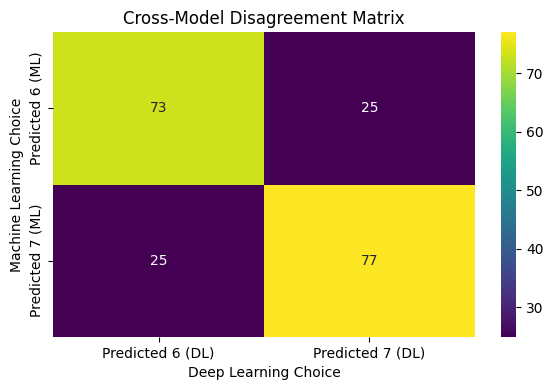

In [56]:
"""As a case study, let's plot the ML-DL Disagreement Matrix on this problem"""

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

preds_dl = y_preds_dl_final.flatten()
preds_ml = y_preds_ml.flatten()

total_samples = len(preds_dl)
matching_mask = (preds_dl == preds_ml)
disputed_mask = ~matching_mask

agreement_rate = np.mean(matching_mask) * 100
total_disputed = np.sum(disputed_mask)

print(f'Agreement Rate: {agreement_rate:.2f}%')
print(f'Disputed Predictions: {total_disputed} out of {total_samples}')

cm = confusion_matrix(preds_ml, preds_dl, labels=[6,7])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Predicted 6 (DL)', 'Predicted 7 (DL)'],
            yticklabels=['Predicted 6 (ML)', 'Predicted 7 (ML)'])
plt.title('Cross-Model Disagreement Matrix')
plt.xlabel('Deep Learning Choice')
plt.ylabel('Machine Learning Choice')
plt.tight_layout()
plt.show()